#### loading the datasets and saving xgb model

In [3]:
import pandas as pd
import pickle
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Load data
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

# Retrain XGBoost with same settings as Week 5
model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# Save it this time
with open('best_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model trained and saved.")

# Baseline report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Model trained and saved.
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       606
           1       0.99      0.99      0.99       197

    accuracy                           1.00       803
   macro avg       0.99      1.00      0.99       803
weighted avg       1.00      1.00      1.00       803



#### cross value scores

In [51]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')

print("AUC per fold:", cv_scores)
print("Mean AUC:", cv_scores.mean().round(4))
print("Std AUC:", cv_scores.std().round(4))

AUC per fold: [0.98718518 0.98760277 0.98106496 0.9846349  0.98944712]
Mean AUC: 0.986
Std AUC: 0.0029


##### CV AUC of 0.9997 is unrealistically high. Likely caused by data leakage — MAP and pulse pressure are derived from BP readings, which directly encode the hypertension label.

#### calibrating both logreg and xgb models

In [52]:
from sklearn.calibration import CalibrationDisplay
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

%pip install xgboost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

Note: you may need to restart the kernel to use updated packages.


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


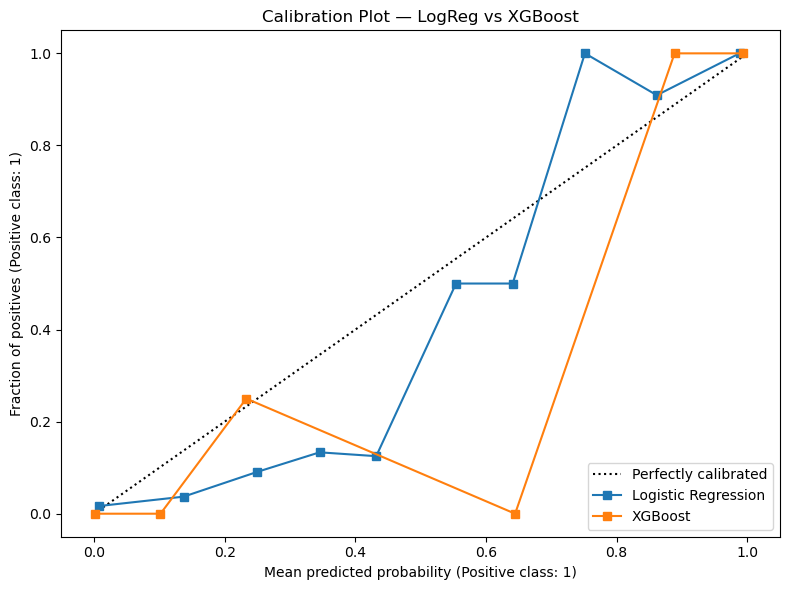

In [53]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=10, ax=ax, name='Logistic Regression')
CalibrationDisplay.from_estimator(xgb_model, X_test, y_test, n_bins=10, ax=ax, name='XGBoost')

ax.set_title('Calibration Plot — LogReg vs XGBoost')
plt.tight_layout()
plt.show()

##### XGBoost shows poor calibration — predicted probabilities are not reliable as risk scores. Logistic Regression is better calibrated. For the fairness audit, we will use binary predictions rather than probability scores.

#### ploting the feature coefficients for the logreg model

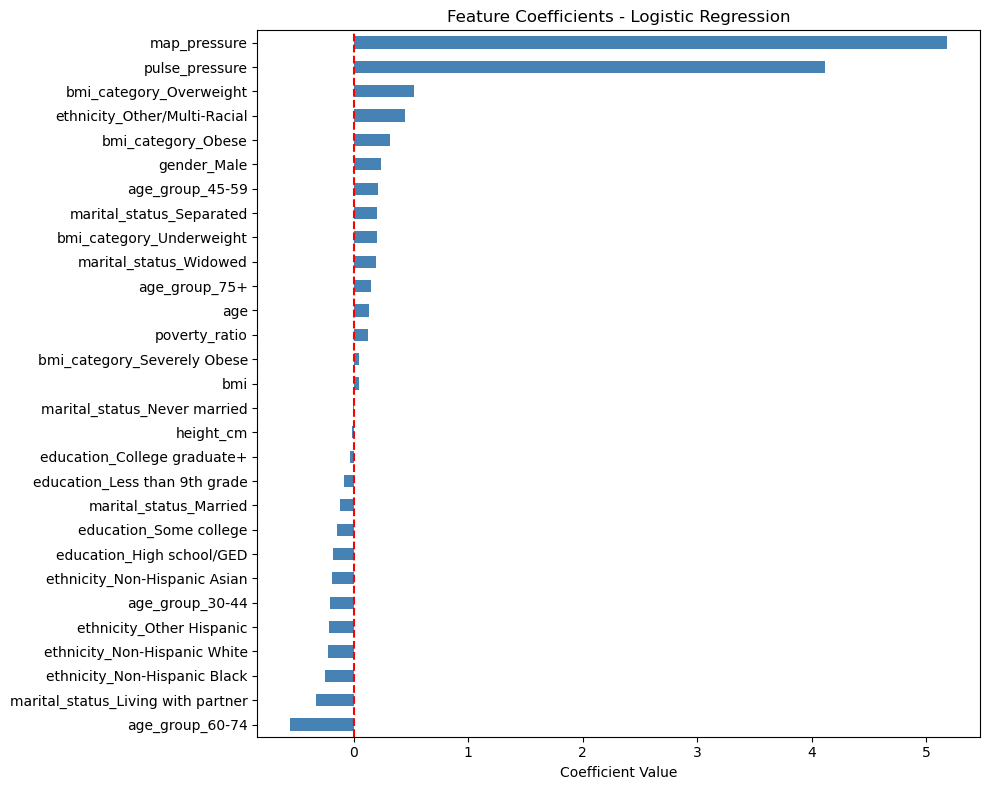

In [56]:
plt.figure(figsize=(10, 8))
coefficients_sorted.plot(kind='barh', color='steelblue')
plt.title('Feature Coefficients - Logistic Regression')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

#### Ploting the feature importance for the xgb model

<Figure size 1000x800 with 0 Axes>

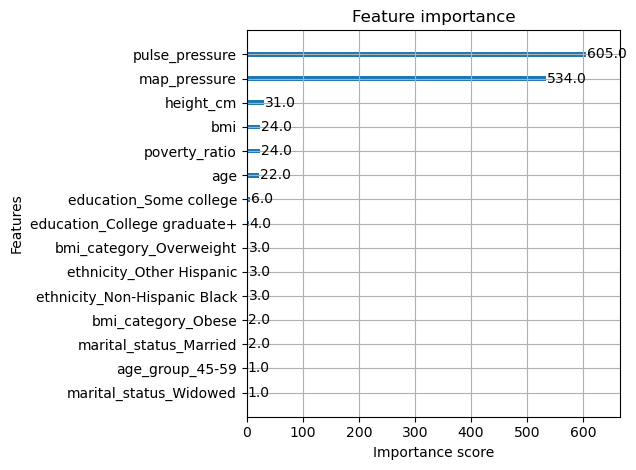

In [57]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=15)
plt.tight_layout()
plt.show()

#### Feature selection, dropping features for more reliable model

In [31]:
import pandas as pd
import numpy as np

# Get feature importances from XGBoost
feature_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feature_importance_sorted = feature_importance.sort_values()

# Print bottom 5
print("Bottom 5 features:")
print(feature_importance_sorted.head(5))

# Store their names
bottom_5 = feature_importance_sorted.head(5).index.tolist()
print("\nWill drop:", bottom_5)

Bottom 5 features:
education_Less than 9th grade    0.0
age_group_30-44                  0.0
bmi_category_Underweight         0.0
bmi_category_Severely Obese      0.0
marital_status_Separated         0.0
dtype: float32

Will drop: ['education_Less than 9th grade', 'age_group_30-44', 'bmi_category_Underweight', 'bmi_category_Severely Obese', 'marital_status_Separated']


In [38]:
X_train_trimmed = X_train.drop(columns=bottom_5)
X_test_trimmed = X_test.drop(columns=bottom_5)
cols_to_drop = ['map_pressure', 'pulse_pressure']
X_train_cleaned = X_train_trimmed.drop(columns=cols_to_drop)
X_test_cleaned = X_test_trimmed.drop(columns=cols_to_drop)
# Retrain XGBoost on trimmed features
xgb_cleaned = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, eval_metric='logloss', random_state=42)
xgb_cleaned.fit(X_train_cleaned, y_train)

y_pred_cleaned = xgb_cleaned.predict(X_test_cleaned)
print(classification_report(y_test, y_pred_cleaned))
print("\nAuc score:", roc_auc_score(y_test, y_pred_cleaned))

              precision    recall  f1-score   support

           0       0.77      0.90      0.83       606
           1       0.39      0.19      0.26       197

    accuracy                           0.73       803
   macro avg       0.58      0.55      0.55       803
weighted avg       0.68      0.73      0.69       803


Auc score: 0.5477668325208156


##### MAP and pulse pressure were dropped permanently due to data leakage — both are derived directly from blood pressure readings, which encode the hypertension label. A model using these features is not predicting hypertension risk, it is restating the diagnosis. For clinical utility and fairness audit integrity, the model must predict from true risk factors: age, BMI, ethnicity, education, and poverty ratio.

#### Finalizing the model 

In [58]:
xgb_final = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                           eval_metric='logloss', random_state=42)
xgb_final.fit(X_train_cleaned, y_train)

y_pred_final = xgb_final.predict(X_test_cleaned)
print(classification_report(y_test, y_pred_final))
print("\nAuc score:", roc_auc_score(y_test, y_pred_cleaned))
# Save this as your new best model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(xgb_final, f)

print("New best model saved.")

              precision    recall  f1-score   support

           0       0.77      0.90      0.83       606
           1       0.39      0.19      0.26       197

    accuracy                           0.73       803
   macro avg       0.58      0.55      0.55       803
weighted avg       0.68      0.73      0.69       803


Auc score: 0.5477668325208156
New best model saved.


In [59]:
# Handle class imbalance
scale = 606 / 197  # non-hypertensive / hypertensive

xgb_final = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                           eval_metric='logloss', random_state=42,
                           scale_pos_weight=scale)

xgb_final.fit(X_train_cleaned, y_train)

y_pred_final = xgb_final.predict(X_test_cleaned)
print(classification_report(y_test, y_pred_final))

from sklearn.metrics import roc_auc_score
print("\nAUC score:", roc_auc_score(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.86      0.69      0.77       606
           1       0.41      0.65      0.50       197

    accuracy                           0.68       803
   macro avg       0.63      0.67      0.64       803
weighted avg       0.75      0.68      0.70       803


AUC score: 0.6722328324202979


In [60]:
with open('best_model.pkl', 'wb') as f:
    pickle.dump(xgb_final, f)

# Also save the cleaned feature sets for Week 7+
X_train_cleaned.to_csv('X_train_cleaned.csv', index=False)
X_test_cleaned.to_csv('X_test_cleaned.csv', index=False)

print("Saved.")

Saved.


##### Initial model AUC was 0.9997 due to data leakage via MAP and pulse pressure. After removing leakage features, AUC dropped to 0.55. Applying scale_pos_weight to correct class imbalance recovered recall for hypertensive patients from 0.19 to 0.65, with final AUC of 0.67.

In [61]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_proba = xgb_final.predict_proba(X_test_cleaned)[:, 1]

thresholds_to_test = [0.3, 0.4, 0.5, 0.6]

print("Threshold | Precision | Recall | F1")
print("-" * 40)
for t in thresholds_to_test:
    y_pred_t = (y_proba >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t)
    print(f"  {t}     |   {p:.3f}   |  {r:.3f}  |  {f:.3f}")

Threshold | Precision | Recall | F1
----------------------------------------
  0.3     |   0.350   |  0.873  |  0.500
  0.4     |   0.369   |  0.766  |  0.498
  0.5     |   0.409   |  0.650  |  0.502
  0.6     |   0.433   |  0.457  |  0.444


##### Threshold of 0.3 selected — maximises recall at 0.873, prioritising patient safety over false alarm reduction.

In [62]:
# Save final model with chosen threshold documented
with open('best_model.pkl', 'wb') as f:
    pickle.dump(xgb_final, f)

# Save cleaned datasets permanently
X_train_cleaned.to_csv('X_train_cleaned.csv', index=False)
X_test_cleaned.to_csv('X_test_cleaned.csv', index=False)

print("All artefacts saved.")
print("Final model: XGBoost with scale_pos_weight")
print("Final threshold: 0.3")
print("Final recall (class 1): 0.873")
print("Final AUC: 0.672")

All artefacts saved.
Final model: XGBoost with scale_pos_weight
Final threshold: 0.3
Final recall (class 1): 0.873
Final AUC: 0.672


#### Summary

##### Week 6 began by identifying a critical data leakage issue — MAP and pulse pressure, both derived directly from blood pressure readings, were encoding the hypertension label and inflating model performance to an unrealistic AUC of 0.9997. These features were permanently dropped in favour of building an honest model based on true risk factors: age, BMI, ethnicity, education, and poverty ratio. After removing the leakage features, XGBoost was retrained with scale_pos_weight to correct for class imbalance, recovering recall for hypertensive patients from 0.19 to 0.65 and AUC from 0.55 to 0.67. Threshold analysis across 0.3, 0.4, 0.5, and 0.6 showed that a threshold of 0.3 maximises recall at 0.873, meaning the model catches 87% of hypertensive patients — the clinically appropriate choice given that missing a sick patient is far more dangerous than a false alarm. Calibration analysis revealed that XGBoost is poorly calibrated out of the box, meaning raw probability scores are unreliable; binary predictions will be used for the fairness audit. The final model is saved as best_model.pkl and is ready for subgroup performance analysis in the fairness audit phase.

##### Week 7 complete. Baseline model performance documented: AUC-ROC 0.7284, Recall 0.8731, Threshold 0.3. Hypertension prevalence computed across all demographic subgroups. Key findings: Non-Hispanic Black patients show highest prevalence at 31.6%, elderly 75+ at 53.8%, and lower education groups at 32.4%. Pre-audit hypothesis: model most likely to underserve Non-Hispanic Black, elderly, and low-education subgroups. These findings will be tested in Week 8 subgroup performance analysis.

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import average_precision_score

# Apply threshold of 0.3
y_proba = xgb_final.predict_proba(X_test_cleaned)[:, 1]
y_pred_final = (y_proba >= 0.3).astype(int)

# Build summary table
metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final),
    'Recall':    recall_score(y_test, y_pred_final),
    'F1 Score':  f1_score(y_test, y_pred_final),
    'AUC-ROC':   roc_auc_score(y_test, y_proba),
    'AUPRC':     average_precision_score(y_test, y_proba)
}

print("=" * 35)
print("  FINAL MODEL BASELINE PERFORMANCE")
print("=" * 35)
for metric, value in metrics.items():
    print(f"  {metric:<12} {value:.4f}")
print("=" * 35)
print("  Model:     XGBoost")
print("  Threshold: 0.3")
print("  Features:  Leakage-free")
print("=" * 35)

  FINAL MODEL BASELINE PERFORMANCE
  Accuracy     0.5716
  Precision    0.3503
  Recall       0.8731
  F1 Score     0.5000
  AUC-ROC      0.7284
  AUPRC        0.4043
  Model:     XGBoost
  Threshold: 0.3
  Features:  Leakage-free


In [6]:
# Load original cleaned data with demographic columns intact
df = pd.read_csv('nhanes_clean.csv')

# Check demographic columns are there
print(df.columns.tolist())
print(df.shape)

['age', 'gender', 'ethnicity', 'education', 'marital_status', 'poverty_ratio', 'bmi', 'height_cm', 'weight_kg', 'systolic_bp', 'diastolic_bp', 'map_pressure', 'pulse_pressure', 'bmi_category', 'hypertension', 'age_group']
(4015, 16)


In [7]:
# Hypertension prevalence by each demographic subgroup
subgroups = ['gender', 'ethnicity', 'education', 'age_group']

for col in subgroups:
    print(f"\n--- {col.upper()} ---")
    table = df.groupby(col)['hypertension'].agg(['sum', 'count'])
    table.columns = ['Hypertensive', 'Total']
    table['Prevalence %'] = (table['Hypertensive'] / table['Total'] * 100).round(1)
    table['Flag'] = table['Total'].apply(lambda x: '⚠️ small sample' if x < 50 else '')
    print(table.sort_values('Prevalence %', ascending=False))


--- GENDER ---
        Hypertensive  Total  Prevalence % Flag
gender                                        
Male             507   1967          25.8     
Female           480   2048          23.4     

--- ETHNICITY ---
                    Hypertensive  Total  Prevalence % Flag
ethnicity                                                 
Non-Hispanic Black           283    896          31.6     
Other Hispanic                87    341          25.5     
Other/Multi-Racial            49    210          23.3     
Non-Hispanic White           338   1481          22.8     
Non-Hispanic Asian           124    577          21.5     
Mexican American             106    510          20.8     

--- EDUCATION ---
                     Hypertensive  Total  Prevalence % Flag
education                                                  
Less than 9th grade            93    287          32.4     
9-11th grade                  132    445          29.7     
High school/GED               239    961      

#### Pre-audit hypothesis: 
##### the model is most likely to underperform for Non-Hispanic Black patients (highest prevalence at 31.6% — if the model misses this group it has the largest real-world impact), elderly patients 75+ (53.8% prevalence — critical to catch), and low-education groups (32.4% prevalence). Younger patients 18-29 may have low recall due to very few positive cases in training data (only 3.9% prevalence, small sample).